In [2]:
import os
from dotenv import load_dotenv
import databento as db
import pandas as pd

load_dotenv()
client = db.Historical(os.environ.get("DATABENTO_API_KEY"))

In [24]:
# !!!ONLY RUN IF THERE IS NO EXISTING DATA IN /data OR IF YOU WANT NEW DATA!!!
data = client.timeseries.get_range(
    dataset="XNAS.ITCH",
    symbols="INTC",
    schema="trades",
    start="2023-01-01",
    end="2026-01-01",
    path="../data/INTC_trades(XNASITCH).dbn.zst",
)

store = db.DBNStore.from_file("../data/INTC_trades(XNASITCH).dbn.zst")
store.to_parquet("../data/INTC_trades(XNASITCH).parquet")

In [25]:
raw = pd.read_parquet(
    "../data/INTC_trades(XNASITCH).parquet",
    filters=[
        ("ts_event", ">=", pd.Timestamp("2023-01-01", tz="UTC")),
        ("ts_event", "<",  pd.Timestamp("2023-02-01", tz="UTC")),
    ],
)

In [26]:
# Keep only valid trades (i.e., those with a non-zero price and size)
df = raw[(raw["price"] > 0) & (raw["size"] > 0)].copy()

# Set the index to the exchange measured timestamp
df = df.set_index("ts_event")

# Convert the index to the New York timezone
df.index = df.index.tz_convert("America/New_York")

# Filter the DataFrame to only include rows between 9:30 AM and 4:00 PM
df = df.between_time("09:30:01", "15:59:59")

# Sanity check the price scale before going further
print(df["price"].describe())

count    677831.000000
mean         28.715135
std           1.016275
min          26.370000
25%          27.880000
50%          28.770000
75%          29.660000
max          30.480000
Name: price, dtype: float64


In [27]:
# Define a daily_rv function that takes df and freq and returns a DataFrame with daily realized volatility
import numpy as np

def daily_rv(df, freq):
    day = df.index.normalize()
    prices = (
        df["price"]
        .groupby(day)
        .resample(freq)
        .last()
        .ffill()
        .droplevel(0)
    )

    #Get opening price for each day
    opens = df["price"].groupby(day).first()

    #Add openings to resampled prices
    prices = pd.concat([opens, prices]).sort_index()
    
    logp = np.log(prices)

    rv_daily = (
        logp.groupby(logp.index.normalize())
        .apply(lambda x: (x.diff() ** 2).sum())
    )

    return rv_daily

In [28]:
# Create a df that contains the daily realized volatility for each frequency in freqs

freqs = ["1s", "2s", "5s", "10s", "30s", "1min", "2min", "5min", "10min", "30min"]

rv = pd.DataFrame({f: daily_rv(df, f) for f in freqs})

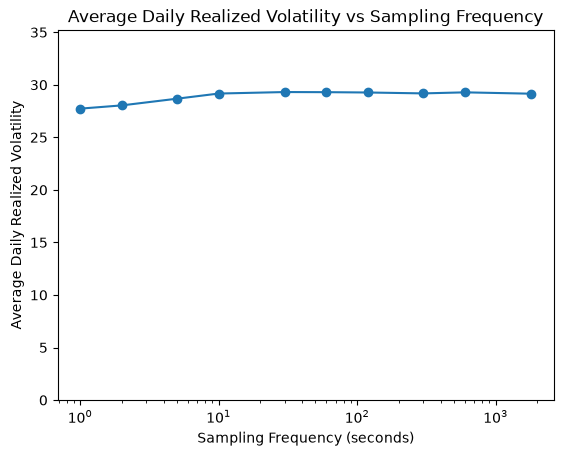

In [29]:
import matplotlib.pyplot as plt

seconds = [1, 2, 5, 10, 30, 60, 120, 300, 600, 1800]

means_annualized = np.sqrt(rv.mean() * 252) * 100  # Annualize and convert to percentage

plt.semilogx(seconds, means_annualized, marker="o")
plt.ylim(0, means_annualized.max() * 1.2)
plt.xlabel("Sampling Frequency (seconds)")
plt.ylabel("Average Daily Realized Volatility")
plt.title("Average Daily Realized Volatility vs Sampling Frequency")
plt.show()

In [30]:
test_freqs = [
    "100ms", "200ms", "500ms",
    "1s", "2s", "3s", "5s", "8s", "10s", "15s", "20s",
    "30s", "45s", "1min", "2min", "5min", "10min",
]

for f in test_freqs:
    g = df["price"].groupby(df.index.normalize()).resample(f).last().droplevel(0)
    print(f, g.isna().sum(), "of", len(g), round(g.isna().mean(), 3))

100ms 4523829 of 4679576 0.967
200ms 2193827 of 2339793 0.938
500ms 806460 of 935919 0.862
1s 354702 of 467960 0.758
2s 140599 of 234000 0.601
3s 75907 of 156000 0.487
5s 30762 of 93600 0.329
8s 11288 of 58500 0.193
10s 6569 of 46800 0.14
15s 2042 of 31200 0.065
20s 753 of 23400 0.032
30s 145 of 15600 0.009
45s 16 of 10400 0.002
1min 2 of 7800 0.0
2min 0 of 3900 0.0
5min 0 of 1560 0.0
10min 0 of 780 0.0


In [31]:
print(df["price"].groupby(df.index.normalize()).count().describe())

count       20.000000
mean     33891.550000
std      15638.258705
min      24159.000000
25%      26552.000000
50%      28794.000000
75%      35756.500000
max      95954.000000
Name: price, dtype: float64
